In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from itertools import combinations
from scipy.stats import mannwhitneyu, gaussian_kde


In [7]:
# ── Paths ──────────────────────────────────────────────────────────────────────
base       = "/Users/ivanatang/Library/CloudStorage/OneDrive-UCB-O365/Shirts Lab/LCA_boltz_models"
runrel     = "prod_md_0p9_cutoff_3dt_64x1_16PME_642dd"
FEAT_TABLE = os.path.join(base, "feat_table.xlsx")
OUT_DIR    = os.path.join(base, "analysis", "nonconsensus_rmsf")
os.makedirs(OUT_DIR, exist_ok=True)

# ── Directory mapping ─────────────────────────────────────────────────────────
TYPE_SUBDIR = {
    "binder":    "binders",
    "nb":        "nonbinders",
    "low_pkt":   "neg_low_pkt",
    "fail_gate": "neg_fail_gate",
}
FEAT_TO_TYPE = {
    "binder":    "binder",
    "nonbinder": "nb",
    "low_pkt":   "low_pkt",
    "fail_gate": "fail_gate",
}

# ── RMSF region files ──────────────────────────────────────
REGIONS = {
    "Gate (r84-90)":             "rmsf_PL_ca_gate.xvg",
    "Latch (r114-118)":          "rmsf_PL_ca_latch.xvg",
    "Lb7a5 (r148-155)":          "rmsf_PL_ca_Lb7a5.xvg",
    "C-term helix (r154-166)":   "rmsf_PL_ca_recoil.xvg",
}
FULL_RMSF_FILE = "rmsf_PL.xvg"
NM_TO_ANG = 10.0

# ── Validated binder motif (positions 1-indexed) ──────────────────────────────
BINDER_MOTIF = {81: 'D', 83: 'L', 92: 'M'}

# ── Subgroup colours and display names ───────────────────────────────────────
SUBGROUP_LABEL = {
    "consensus_binder":       "Consensus Binder",
    "nonconsensus_binder":    "Non-consensus Binder",
    "nonconsensus_nonbinder": "Non-consensus Nonbinder",
    "consensus_nonbinder":    "Consensus Nonbinder",
}
SUBGROUP_COLOR = {
    "consensus_binder":       "#648FFF",
    "nonconsensus_binder":    "#91c4ff",
    "nonconsensus_nonbinder": "#ff91bb",
    "consensus_nonbinder":    "#DC267F",
}
SUBGROUP_ORDER = [
    "consensus_binder",
    "nonconsensus_binder",
    "nonconsensus_nonbinder",
    "consensus_nonbinder",
]
SUBGROUP_ABBREV = {
    "consensus_binder":       "CB",
    "nonconsensus_binder":    "NCB",
    "nonconsensus_nonbinder": "NCNB",
    "consensus_nonbinder":    "CNB",
}

# ── xvg reader ────────────────────────────────────────────────────────────────
def get_data(file):
    x_data, y_data = [], []
    with open(file, 'r') as f:
        for line in f:
            if not line.startswith(('@', '#')):
                parts = line.strip().split()
                if len(parts) >= 2:
                    try:
                        x_data.append(float(parts[0]))
                        y_data.append(float(parts[1]))
                    except ValueError:
                        pass
    return np.array(x_data), np.array(y_data)

# ── Statistical helpers ───────────────────────────────────────────────────────
def p_label(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

def compute_pairwise_bonferroni(df, region, groups):
    pairs = list(combinations(groups, 2))
    raw   = {}
    for g1, g2 in pairs:
        v1 = df.loc[df['subgroup'] == g1, region].dropna().values
        v2 = df.loc[df['subgroup'] == g2, region].dropna().values
        if len(v1) >= 2 and len(v2) >= 2:
            _, p = mannwhitneyu(v1, v2, alternative='two-sided')
            raw[(g1, g2)] = p
        else:
            raw[(g1, g2)] = np.nan
    n_valid = sum(1 for v in raw.values() if not np.isnan(v))
    return {k: min(v * n_valid, 1.0) if not np.isnan(v) else np.nan
            for k, v in raw.items()}

def add_sig_brackets(ax, group_positions, pval_dict, data_ymax, data_range):
    sig = [(g1, g2, p) for (g1, g2), p in pval_dict.items()
           if not np.isnan(p) and p < 0.05]
    sig.sort(key=lambda t: abs(group_positions[t[1]] - group_positions[t[0]]))
    y_step = 0.11 * data_range
    tip_h  = 0.025 * data_range
    base_y = data_ymax + 0.06 * data_range
    for level, (g1, g2, p) in enumerate(sig):
        x1, x2 = group_positions[g1], group_positions[g2]
        y = base_y + level * y_step
        ax.plot([x1, x1, x2, x2], [y, y + tip_h, y + tip_h, y],
                lw=0.8, color='black', clip_on=False)
        ax.text((x1 + x2) / 2, y + tip_h * 1.2, p_label(p),
                ha='center', va='bottom', fontsize=6, color='black')
    if sig:
        needed_top = base_y + len(sig) * y_step + y_step
        ax.set_ylim(top=max(ax.get_ylim()[1], needed_top))


In [8]:
# ── Load sequences + classify into subgroups ─────────────────────────────────
# Consensus threshold is derived from BINDER_MOTIF so adding/removing positions
# in Cell 1 automatically updates the classification without editing this cell.
#
# Consensus Binder     — binder with ALL motif AAs (score == n_motif_positions)
# Non-consensus Binder — binder missing ≥1 motif AA (score < n_motif_positions)
# Non-consensus Nonbinder — nonbinder carrying ≥1 binder motif AA (score >= 1)
# Consensus Nonbinder  — nonbinder with no binder motif AAs (score == 0)

N_MOTIF = len(BINDER_MOTIF)   # total number of positions in the motif

ft = pd.read_excel(FEAT_TABLE, sheet_name='all_feats_500ns')
ft.columns = ft.columns.str.strip()
rename_map = {c: c.lower() for c in ft.columns if c.lower() in ['name','group','sequence']}
ft = ft.rename(columns=rename_map)
ft['group']    = ft['group'].astype(str).str.strip().str.lower()
ft['sequence'] = ft['sequence'].astype(str).str.strip()
ft = ft[ft['group'].isin(FEAT_TO_TYPE)].reset_index(drop=True)
print(f'Loaded {len(ft)} sequences.')
print(ft['group'].value_counts().to_string())
print(f'\nMotif positions ({N_MOTIF}): ' +
      ', '.join(f'pos{p}={aa}' for p, aa in BINDER_MOTIF.items()))

# Motif score = number of motif positions carrying the binder AA
def motif_score(seq):
    return sum(seq[pos - 1].upper() == aa for pos, aa in BINDER_MOTIF.items())

ft['motif_score'] = ft['sequence'].apply(motif_score)
ft['is_binder']   = ft['group'] == 'binder'

# Classify into four subgroups — thresholds scale with N_MOTIF
def classify(row):
    if row['is_binder']:
        return ('consensus_binder'
                if row['motif_score'] == N_MOTIF
                else 'nonconsensus_binder')
    else:
        return ('nonconsensus_nonbinder'
                if row['motif_score'] >= 1
                else 'consensus_nonbinder')

ft['subgroup'] = ft.apply(classify, axis=1)

# Derive seq_type from name suffix
def get_seq_type(name):
    if name.endswith('_binder'):    return 'binder'
    if name.endswith('_nb'):        return 'nb'
    if name.endswith('_low_pkt'):   return 'low_pkt'
    if name.endswith('_fail_gate'): return 'fail_gate'
    return None

ft['folder_name'] = ft['name']
ft['seq_type']    = ft['name'].apply(get_seq_type)
ft = ft[ft['seq_type'].notna()].reset_index(drop=True)

print('\n=== Subgroup classification ===')
print(f'Consensus threshold: {N_MOTIF}/{N_MOTIF} motif positions match')
for sg in SUBGROUP_ORDER:
    sub = ft[ft['subgroup'] == sg]
    print(f'\n{SUBGROUP_LABEL[sg]} (n={len(sub)}):')
    for _, row in sub.iterrows():
        aas = ', '.join(f'pos{p}={row["sequence"][p-1].upper()}'
                        for p in BINDER_MOTIF)
        match = ', '.join(
            ('✓' if row['sequence'][p-1].upper() == aa else f'✗({row["sequence"][p-1].upper()})')
            for p, aa in BINDER_MOTIF.items()
        )
        print(f'  {row["name"]:<30}  score={row["motif_score"]}/{N_MOTIF}  [{aas}]  [{match}]')

Loaded 130 sequences.
group
nonbinder    74
binder       37
fail_gate    10
low_pkt       9

Motif positions (3): pos81=D, pos83=L, pos92=M

=== Subgroup classification ===
Consensus threshold: 3/3 motif positions match

Consensus Binder (n=33):
  seq16_binder                    score=3/3  [pos81=D, pos83=L, pos92=M]  [✓, ✓, ✓]
  seq14_binder                    score=3/3  [pos81=D, pos83=L, pos92=M]  [✓, ✓, ✓]
  seq10_binder                    score=3/3  [pos81=D, pos83=L, pos92=M]  [✓, ✓, ✓]
  seq17_binder                    score=3/3  [pos81=D, pos83=L, pos92=M]  [✓, ✓, ✓]
  seq39_binder                    score=3/3  [pos81=D, pos83=L, pos92=M]  [✓, ✓, ✓]
  pair_3069_binder                score=3/3  [pos81=D, pos83=L, pos92=M]  [✓, ✓, ✓]
  pair_3070_binder                score=3/3  [pos81=D, pos83=L, pos92=M]  [✓, ✓, ✓]
  pair_3074_binder                score=3/3  [pos81=D, pos83=L, pos92=M]  [✓, ✓, ✓]
  pair_3092_binder                score=3/3  [pos81=D, pos83=L, pos92=M]  [✓, ✓, ✓

In [9]:
# ── Load regional RMSF per sequence ──────────────────────────────────────────
rows    = []
skipped = []

for _, row in ft.iterrows():
    rec = {
        'folder_name': row['folder_name'],
        'subgroup':    row['subgroup'],
        'motif_score': row['motif_score'],
    }
    for region_name, region_fname in REGIONS.items():
        fpath = os.path.join(base, TYPE_SUBDIR[row['seq_type']],
                             row['folder_name'], runrel, region_fname)
        if not os.path.exists(fpath):
            skipped.append((row['folder_name'], region_name))
            rec[region_name] = np.nan
        else:
            print(f"Reading: {fpath}")
            _, rmsf = get_data(fpath)
            rec[region_name] = round(np.mean(rmsf * NM_TO_ANG), 6)
    rows.append(rec)

rmsf_df = pd.DataFrame(rows)

if skipped:
    print(f'Missing files: {len(skipped)}')
    for fn, rn in skipped[:10]:
        print(f'  {fn} -- {rn}')

print(f'\nLoaded RMSF data for {rmsf_df["folder_name"].nunique()} sequences')
print('\nSubgroup counts:')
print(rmsf_df['subgroup'].value_counts().to_string())
print('\nMean RMSF per subgroup per region:')
print(rmsf_df.groupby('subgroup')[list(REGIONS.keys())].mean().round(3).to_string())


Reading: /Users/ivanatang/Library/CloudStorage/OneDrive-UCB-O365/Shirts Lab/LCA_boltz_models/binders/seq16_binder/prod_md_0p9_cutoff_3dt_64x1_16PME_642dd/rmsf_PL_ca_gate.xvg
Reading: /Users/ivanatang/Library/CloudStorage/OneDrive-UCB-O365/Shirts Lab/LCA_boltz_models/binders/seq16_binder/prod_md_0p9_cutoff_3dt_64x1_16PME_642dd/rmsf_PL_ca_latch.xvg
Reading: /Users/ivanatang/Library/CloudStorage/OneDrive-UCB-O365/Shirts Lab/LCA_boltz_models/binders/seq16_binder/prod_md_0p9_cutoff_3dt_64x1_16PME_642dd/rmsf_PL_ca_Lb7a5.xvg
Reading: /Users/ivanatang/Library/CloudStorage/OneDrive-UCB-O365/Shirts Lab/LCA_boltz_models/binders/seq16_binder/prod_md_0p9_cutoff_3dt_64x1_16PME_642dd/rmsf_PL_ca_recoil.xvg
Reading: /Users/ivanatang/Library/CloudStorage/OneDrive-UCB-O365/Shirts Lab/LCA_boltz_models/binders/seq14_binder/prod_md_0p9_cutoff_3dt_64x1_16PME_642dd/rmsf_PL_ca_gate.xvg
Reading: /Users/ivanatang/Library/CloudStorage/OneDrive-UCB-O365/Shirts Lab/LCA_boltz_models/binders/seq14_binder/prod_md_0p9_

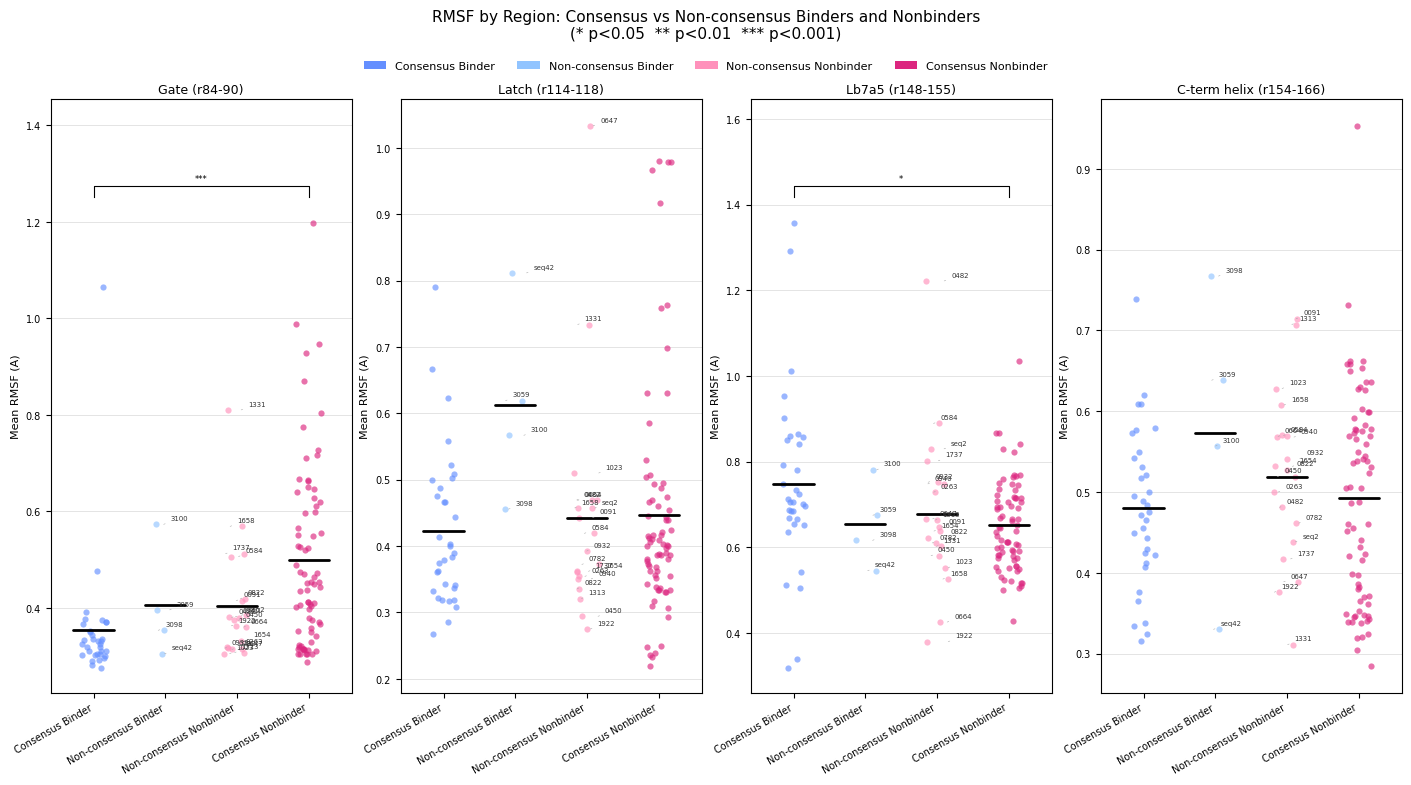

In [10]:
# ── Strip plot: RMSF by region, coloured by subgroup ─────────────────────────
region_names    = list(REGIONS.keys())
n_regions       = len(region_names)
group_positions = {g: i for i, g in enumerate(SUBGROUP_ORDER)}
rng             = np.random.default_rng(42)

fig1, axes1 = plt.subplots(1, n_regions, figsize=(3.5 * n_regions, 7),
                            sharey=False, constrained_layout=True)

for ax, region in zip(axes1, region_names):
    all_vals   = rmsf_df[region].dropna().values
    data_ymax  = all_vals.max()  if len(all_vals) > 0 else 1.0
    data_range = (all_vals.max() - all_vals.min()) if len(all_vals) > 1 else 1.0

    for x_pos, sg in enumerate(SUBGROUP_ORDER):
        vals  = rmsf_df.loc[rmsf_df['subgroup'] == sg, region].dropna().values
        color = SUBGROUP_COLOR[sg]
        if len(vals) == 0:
            continue
        jitter = rng.uniform(-0.18, 0.18, size=len(vals))
        ax.scatter(x_pos + jitter, vals,
                   color=color, alpha=0.65, s=20, linewidths=0, zorder=2)
        ax.plot([x_pos - 0.28, x_pos + 0.28], [np.mean(vals)] * 2,
                color='black', lw=2.0, solid_capstyle='round', zorder=3)
        # Annotate non-consensus sequences by name
        if sg in ('nonconsensus_binder', 'nonconsensus_nonbinder'):
            sub_rows = rmsf_df[rmsf_df['subgroup'] == sg].dropna(subset=[region]).reset_index(drop=True)
            j_vals   = rng.uniform(-0.18, 0.18, size=len(sub_rows))
            for idx2, srow in sub_rows.iterrows():
                short = (srow['folder_name']
                         .replace('_binder','').replace('_nb','')
                         .replace('pair_','').replace('_low_pkt','').replace('_fail_gate',''))
                ax.annotate(short,
                            xy=(x_pos + j_vals[idx2], srow[region]),
                            xytext=(5, 3), textcoords='offset points',
                            fontsize=5, color='#333333',
                            arrowprops=dict(arrowstyle='-', lw=0.4, color='#aaaaaa'))

    ax.set_title(region, fontsize=9, pad=4)
    ax.set_xticks(range(len(SUBGROUP_ORDER)))
    ax.set_xticklabels([SUBGROUP_LABEL[sg] for sg in SUBGROUP_ORDER],
                       fontsize=7, rotation=30, ha='right')
    ax.set_ylabel('Mean RMSF (A)', fontsize=8)
    ax.tick_params(axis='y', labelsize=7)
    ax.grid(True, axis='y', alpha=0.4, lw=0.6)
    ax.set_xlim(-0.6, len(SUBGROUP_ORDER) - 0.4)
    pval_dict = compute_pairwise_bonferroni(rmsf_df, region, SUBGROUP_ORDER)
    add_sig_brackets(ax, group_positions, pval_dict, data_ymax, data_range)

legend_handles = [mpatches.Patch(facecolor=SUBGROUP_COLOR[sg], label=SUBGROUP_LABEL[sg])
                  for sg in SUBGROUP_ORDER]
fig1.legend(handles=legend_handles, loc='upper center', ncol=4,
            fontsize=8, frameon=False, bbox_to_anchor=(0.5, 1.04))
fig1.suptitle(
    'RMSF by Region: Consensus vs Non-consensus Binders and Nonbinders\n'
    '(* p<0.05  ** p<0.01  *** p<0.001)',
    fontsize=11, y=1.10)
fig1.savefig(os.path.join(OUT_DIR, 'rmsf_nonconsensus_strip.png'), dpi=300, bbox_inches='tight')
plt.show()


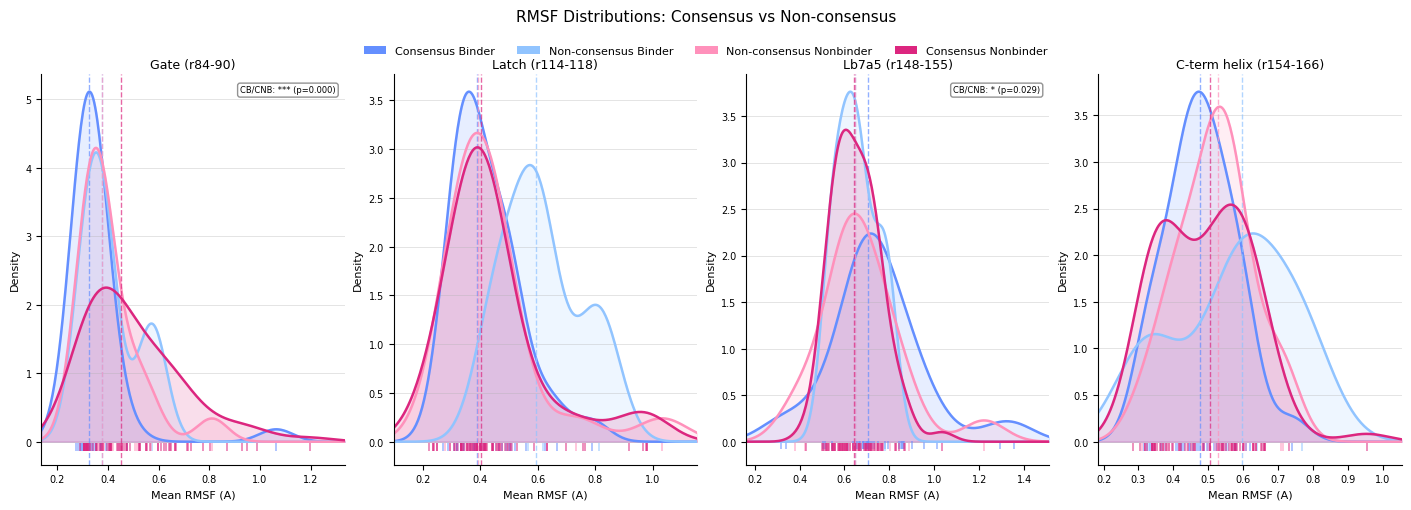

In [11]:
# ── KDE distributions per region ─────────────────────────────────────────────
fig2, axes2 = plt.subplots(1, n_regions, figsize=(3.5 * n_regions, 4.5),
                            sharey=False, constrained_layout=True)

for ax, region in zip(axes2, region_names):
    x_min, x_max = np.inf, -np.inf
    group_data = {}
    for sg in SUBGROUP_ORDER:
        vals = rmsf_df.loc[rmsf_df['subgroup'] == sg, region].dropna().values
        if len(vals) >= 2:
            group_data[sg] = vals
            x_min = min(x_min, vals.min())
            x_max = max(x_max, vals.max())
    pad    = max((x_max - x_min) * 0.15, 0.01)
    x_grid = np.linspace(x_min - pad, x_max + pad, 300)
    y_max_all = 0
    for sg, vals in group_data.items():
        color = SUBGROUP_COLOR[sg]
        kde   = gaussian_kde(vals, bw_method=0.5)
        y     = kde(x_grid)
        y_max_all = max(y_max_all, y.max())
        ax.plot(x_grid, y, color=color, lw=1.8,
                label=f'{SUBGROUP_LABEL[sg]} (n={len(vals)})')
        ax.fill_between(x_grid, y, alpha=0.15, color=color)
        ax.plot(vals, np.full_like(vals, -0.015 * y_max_all),
                '|', color=color, alpha=0.6, ms=6, mew=1.2)
        ax.axvline(np.median(vals), color=color, lw=1.0, ls='--', alpha=0.7)
    pval_dict = compute_pairwise_bonferroni(rmsf_df, region, SUBGROUP_ORDER)
    sig_lines = [
        f'{SUBGROUP_ABBREV[g1]}/{SUBGROUP_ABBREV[g2]}: {p_label(p)} (p={p:.3f})'
        for (g1, g2), p in pval_dict.items()
        if not np.isnan(p) and p < 0.05
    ]
    if sig_lines:
        ax.text(0.97, 0.97, '\n'.join(sig_lines), transform=ax.transAxes,
                ha='right', va='top', fontsize=6,
                bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', alpha=0.85))
    ax.set_title(region, fontsize=9, pad=4)
    ax.set_xlabel('Mean RMSF (A)', fontsize=8)
    ax.set_ylabel('Density', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(True, axis='y', alpha=0.4, lw=0.6)
    ax.set_xlim(x_min - pad, x_max + pad)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig2.legend(handles=legend_handles, loc='upper center', ncol=4,
            fontsize=8, frameon=False, bbox_to_anchor=(0.5, 1.04))
fig2.suptitle('RMSF Distributions: Consensus vs Non-consensus', fontsize=11, y=1.10)
fig2.savefig(os.path.join(OUT_DIR, 'rmsf_nonconsensus_kde.png'), dpi=300, bbox_inches='tight')
plt.show()


Reading: /Users/ivanatang/Library/CloudStorage/OneDrive-UCB-O365/Shirts Lab/LCA_boltz_models/binders/seq16_binder/prod_md_0p9_cutoff_3dt_64x1_16PME_642dd/rmsf_PL.xvg
Reading: /Users/ivanatang/Library/CloudStorage/OneDrive-UCB-O365/Shirts Lab/LCA_boltz_models/binders/seq14_binder/prod_md_0p9_cutoff_3dt_64x1_16PME_642dd/rmsf_PL.xvg
Reading: /Users/ivanatang/Library/CloudStorage/OneDrive-UCB-O365/Shirts Lab/LCA_boltz_models/binders/seq10_binder/prod_md_0p9_cutoff_3dt_64x1_16PME_642dd/rmsf_PL.xvg
Reading: /Users/ivanatang/Library/CloudStorage/OneDrive-UCB-O365/Shirts Lab/LCA_boltz_models/binders/seq17_binder/prod_md_0p9_cutoff_3dt_64x1_16PME_642dd/rmsf_PL.xvg
Reading: /Users/ivanatang/Library/CloudStorage/OneDrive-UCB-O365/Shirts Lab/LCA_boltz_models/binders/seq39_binder/prod_md_0p9_cutoff_3dt_64x1_16PME_642dd/rmsf_PL.xvg
Reading: /Users/ivanatang/Library/CloudStorage/OneDrive-UCB-O365/Shirts Lab/LCA_boltz_models/binders/seq42_binder/prod_md_0p9_cutoff_3dt_64x1_16PME_642dd/rmsf_PL.xvg
Read

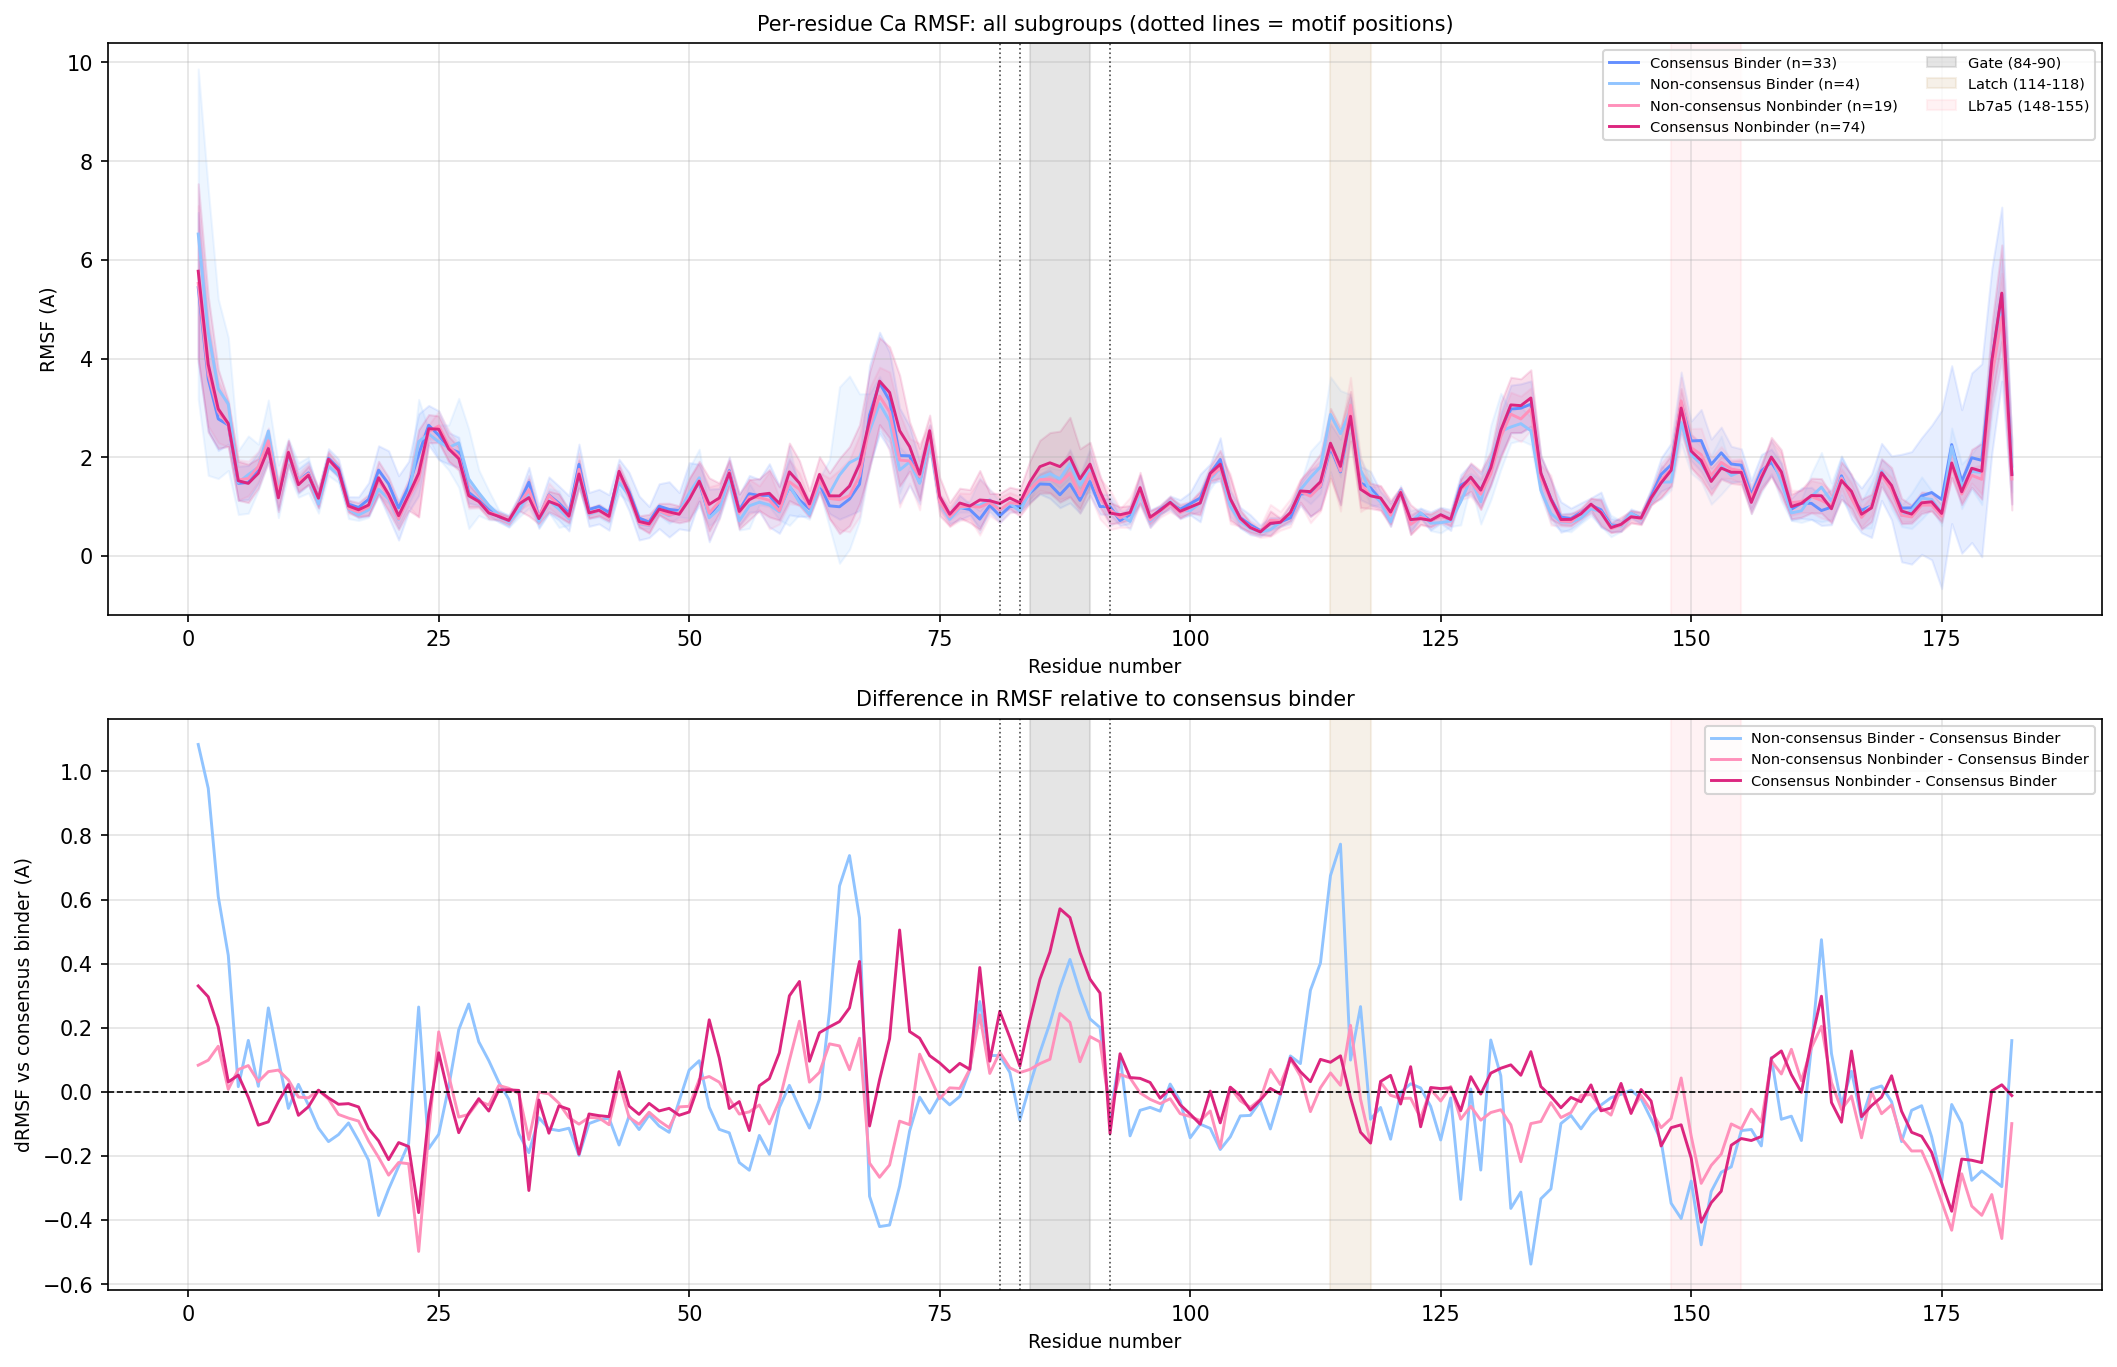

In [12]:
# ── Per-residue RMSF profiles: all subgroups + difference from consensus binder
profile_data = {sg: {} for sg in SUBGROUP_ORDER}

for _, row in ft.iterrows():
    sg    = row['subgroup']
    fpath = os.path.join(base, TYPE_SUBDIR[row['seq_type']],
                         row['folder_name'], runrel, FULL_RMSF_FILE)
    print(f"Reading: {fpath}")
    if not os.path.exists(fpath):
        continue
    x_data, y_data = get_data(fpath)
    for resid, rmsf in zip(x_data.astype(int), y_data * NM_TO_ANG):
        profile_data[sg].setdefault(resid, []).append(rmsf)

all_resid_sets = [set(d.keys()) for d in profile_data.values() if d]
common_resids  = sorted(set.intersection(*all_resid_sets)) if all_resid_sets else []
residues       = np.array(common_resids)

fig3, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(14, 9), dpi=150,
                                       constrained_layout=True)

# Top panel: mean +/- SD per subgroup
for sg in SUBGROUP_ORDER:
    d = profile_data[sg]
    if not d or not common_resids:
        continue
    means = np.array([np.mean(d[r]) for r in common_resids])
    sds   = np.array([np.std(d[r], ddof=1) if len(d[r]) > 1 else 0.0
                      for r in common_resids])
    n_seq = len(d[common_resids[0]])
    ax_top.plot(residues, means, color=SUBGROUP_COLOR[sg], lw=1.4,
                label=f'{SUBGROUP_LABEL[sg]} (n={n_seq})')
    ax_top.fill_between(residues, means - sds, means + sds,
                        color=SUBGROUP_COLOR[sg], alpha=0.15)

ax_top.axvspan(84,  90,  color='grey', alpha=0.2, label='Gate (84-90)')
ax_top.axvspan(114, 118, color='tan',  alpha=0.2, label='Latch (114-118)')
ax_top.axvspan(148, 155, color='pink', alpha=0.2, label='Lb7a5 (148-155)')
for pos in BINDER_MOTIF:
    ax_top.axvline(pos, color='black', lw=0.8, ls=':', alpha=0.7)
ax_top.set_xlabel('Residue number', fontsize=9)
ax_top.set_ylabel('RMSF (A)', fontsize=9)
ax_top.set_title('Per-residue Ca RMSF: all subgroups (dotted lines = motif positions)', fontsize=10)
ax_top.legend(fontsize=7, ncol=2)
ax_top.grid(True, alpha=0.35)

# Bottom panel: difference relative to consensus binder
cb_means = np.array([np.mean(profile_data['consensus_binder'].get(r, [0]))
                     for r in common_resids])
for sg in ['nonconsensus_binder', 'nonconsensus_nonbinder', 'consensus_nonbinder']:
    d = profile_data[sg]
    if not d:
        continue
    means = np.array([np.mean(d[r]) for r in common_resids])
    ax_bot.plot(residues, means - cb_means, color=SUBGROUP_COLOR[sg],
                lw=1.4, label=f'{SUBGROUP_LABEL[sg]} - Consensus Binder')

ax_bot.axhline(0, color='black', lw=0.8, ls='--')
ax_bot.axvspan(84,  90,  color='grey', alpha=0.2)
ax_bot.axvspan(114, 118, color='tan',  alpha=0.2)
ax_bot.axvspan(148, 155, color='pink', alpha=0.2)
for pos in BINDER_MOTIF:
    ax_bot.axvline(pos, color='black', lw=0.8, ls=':', alpha=0.7)
ax_bot.set_xlabel('Residue number', fontsize=9)
ax_bot.set_ylabel('dRMSF vs consensus binder (A)', fontsize=9)
ax_bot.set_title('Difference in RMSF relative to consensus binder', fontsize=10)
ax_bot.legend(fontsize=7)
ax_bot.grid(True, alpha=0.35)

fig3.savefig(os.path.join(OUT_DIR, 'rmsf_nonconsensus_profile.png'),
             dpi=300, bbox_inches='tight')
plt.show()


In [13]:
# ── Summary table + pairwise statistics ──────────────────────────────────────
region_names = list(REGIONS.keys())
summary_rows = []
for sg in SUBGROUP_ORDER:
    sub = rmsf_df[rmsf_df['subgroup'] == sg]
    row = {'subgroup': SUBGROUP_LABEL[sg], 'n': len(sub)}
    for region in region_names:
        vals = sub[region].dropna().values
        row[f'{region} mean'] = round(np.mean(vals), 3) if len(vals) > 0 else np.nan
        row[f'{region} SD']   = round(np.std(vals, ddof=1), 3) if len(vals) > 1 else np.nan
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index('subgroup')
print('=== RMSF Summary by Subgroup ===')
print(summary_df.to_string())

print('\n=== Pairwise Mann-Whitney U (Bonferroni-corrected) ===')
for region in region_names:
    print(f'\n{region}:')
    pvals = compute_pairwise_bonferroni(rmsf_df, region, SUBGROUP_ORDER)
    for (g1, g2), p in pvals.items():
        if not np.isnan(p):
            print(f'  {SUBGROUP_ABBREV[g1]} vs {SUBGROUP_ABBREV[g2]}: p={p:.4f} {p_label(p)}')

rmsf_df.to_csv(os.path.join(OUT_DIR, 'rmsf_nonconsensus_per_sequence.csv'), index=False)
summary_df.to_csv(os.path.join(OUT_DIR, 'rmsf_nonconsensus_summary.csv'))
print(f'\nOutputs written to: {OUT_DIR}')


=== RMSF Summary by Subgroup ===
                          n  Gate (r84-90) mean  Gate (r84-90) SD  Latch (r114-118) mean  Latch (r114-118) SD  Lb7a5 (r148-155) mean  Lb7a5 (r148-155) SD  C-term helix (r154-166) mean  C-term helix (r154-166) SD
subgroup                                                                                                                                                                                                           
Consensus Binder         33               0.354             0.133                  0.423                0.117                  0.747                0.212                         0.480                       0.097
Non-consensus Binder      4               0.407             0.117                  0.613                0.149                  0.654                0.100                         0.573                       0.184
Non-consensus Nonbinder  19               0.404             0.124                  0.443                0.175          

Loaded gate-latch timeseries for 130 sequences

Gate-latch summary per subgroup (mean across sequences):
                        mean_A   sd_A  closed_pct
subgroup                                         
consensus_binder        10.119  1.194      38.545
consensus_nonbinder     10.406  1.431      39.081
nonconsensus_binder     10.800  1.350      20.718
nonconsensus_nonbinder   9.942  1.287      41.451


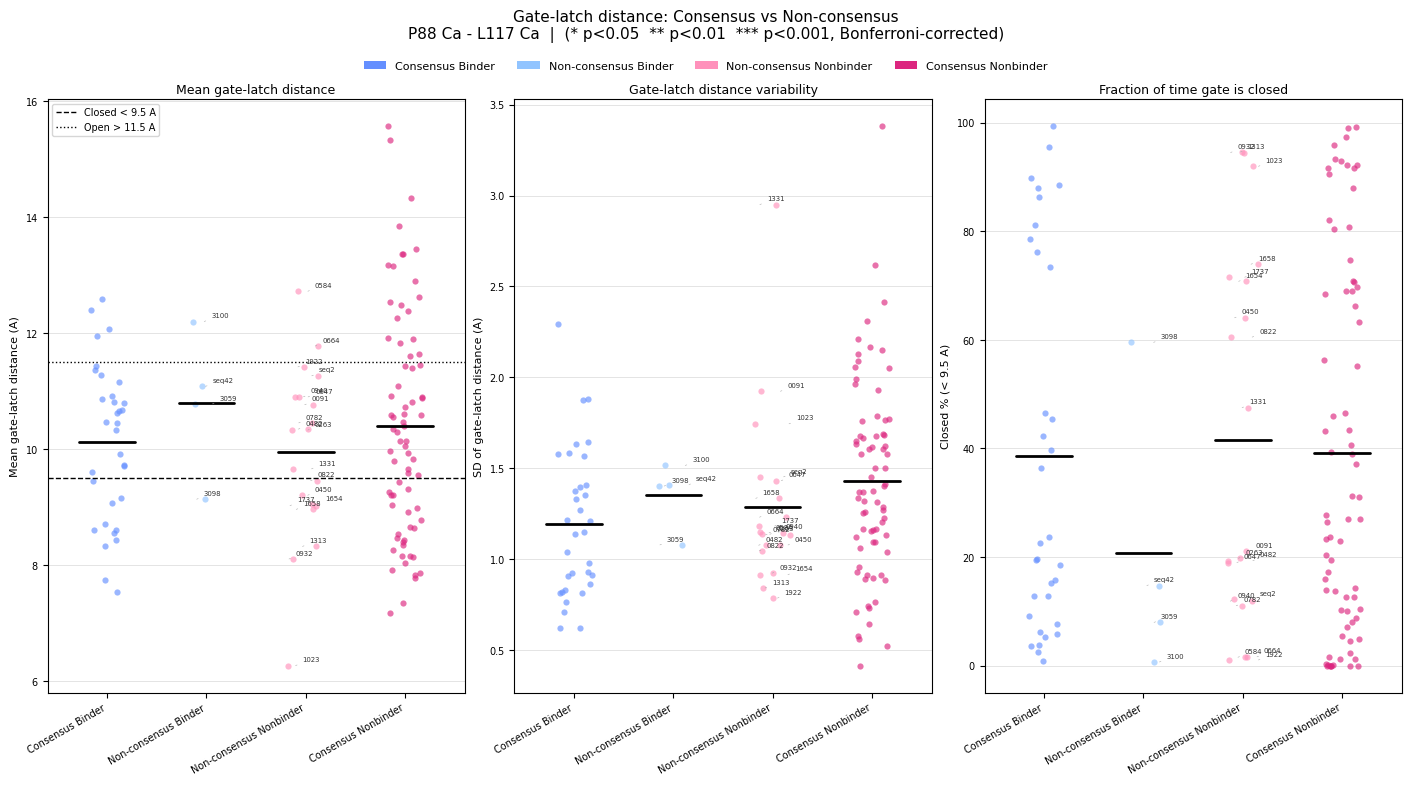

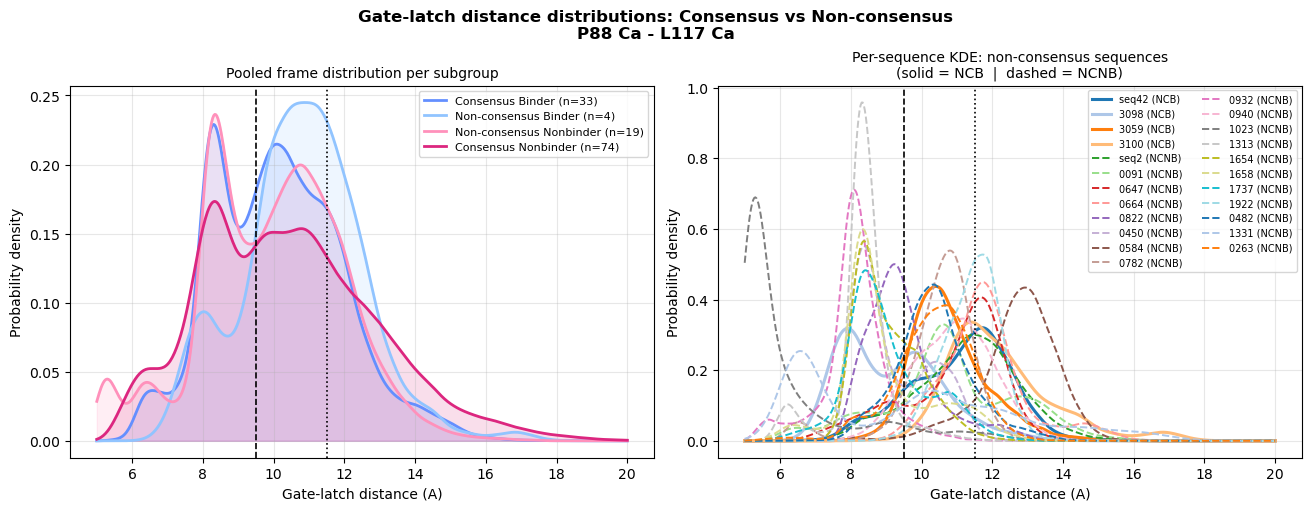


=== Gate-latch summary by subgroup ===
                        mean_A          sd_A        closed_pct         open_pct        
                          mean    std   mean    std       mean     std     mean     std
subgroup                                                                               
consensus_binder        10.119  1.347  1.194  0.406     38.545  34.067   22.357  23.194
consensus_nonbinder     10.406  1.950  1.431  0.540     39.081  34.078   30.989  32.893
nonconsensus_binder     10.800  1.267  1.350  0.189     20.718  26.500   33.360  24.997
nonconsensus_nonbinder   9.942  1.512  1.287  0.495     41.451  34.371   22.472  24.651

=== Pairwise Mann-Whitney U (Bonferroni-corrected) ===

Mean distance (A):
  CB vs NCB: p=1.0000 ns
  CB vs NCNB: p=1.0000 ns
  CB vs CNB: p=1.0000 ns
  NCB vs NCNB: p=1.0000 ns
  NCB vs CNB: p=1.0000 ns
  NCNB vs CNB: p=1.0000 ns

Closed %:
  CB vs NCB: p=1.0000 ns
  CB vs NCNB: p=1.0000 ns
  CB vs CNB: p=1.0000 ns
  NCB vs NCNB: p=0.9703 n

In [14]:
# ── Gate-latch distance: consensus vs non-consensus ─────────────────────────
# Reuses base, runrel, TYPE_SUBDIR, NM_TO_ANG, BINDER_MOTIF, SUBGROUP_*,
# get_data, p_label, compute_pairwise_bonferroni, add_sig_brackets, ft
# from earlier cells — run cells 0-2 first.

# ── Gate-latch specific constants ─────────────────────────────────────────────
CLOSED_THRESHOLD = 0.95    # nm  → 9.5 Å
OPEN_THRESHOLD   = 1.15    # nm  → 11.5 Å
GL_FILE          = 'gate_latch_timeseries.xvg'   # P88 Cα – L117 Cα
N_MOTIF          = len(BINDER_MOTIF)

OUT_DIR_GL = os.path.join(base, 'analysis', 'nonconsensus_gate_latch')
os.makedirs(OUT_DIR_GL, exist_ok=True)

# ── Helpers ───────────────────────────────────────────────────────────────────
def short_name(folder_name):
    parts = folder_name.split('_')
    if parts[0] == 'pair' and len(parts) >= 2:
        return parts[1]
    if folder_name.startswith('seq'):
        return folder_name.split('_')[0]
    return folder_name

_rng             = np.random.default_rng(42)
_group_positions = {g: i for i, g in enumerate(SUBGROUP_ORDER)}
_legend_handles  = [mpatches.Patch(facecolor=SUBGROUP_COLOR[sg],
                                     label=SUBGROUP_LABEL[sg])
                    for sg in SUBGROUP_ORDER]

def _strip_ax(ax, df, col, ylabel, annotate_nc=True):
    """Strip plot with mean bar and significance brackets for one metric."""
    all_vals   = df[col].dropna().values
    data_ymax  = all_vals.max()  if len(all_vals) > 0 else 1.0
    data_range = (all_vals.max() - all_vals.min()) if len(all_vals) > 1 else 1.0
    for x_pos, sg in enumerate(SUBGROUP_ORDER):
        vals = df.loc[df['subgroup'] == sg, col].dropna().values
        if len(vals) == 0:
            continue
        color  = SUBGROUP_COLOR[sg]
        jitter = _rng.uniform(-0.18, 0.18, size=len(vals))
        ax.scatter(x_pos + jitter, vals,
                   color=color, alpha=0.65, s=20, linewidths=0, zorder=2)
        ax.plot([x_pos - 0.28, x_pos + 0.28], [np.mean(vals)] * 2,
                color='black', lw=2.0, solid_capstyle='round', zorder=3)
        if annotate_nc and sg in ('nonconsensus_binder', 'nonconsensus_nonbinder'):
            sub_rows = df[df['subgroup'] == sg].dropna(subset=[col]).reset_index(drop=True)
            j_vals   = _rng.uniform(-0.18, 0.18, size=len(sub_rows))
            for idx2, srow in sub_rows.iterrows():
                ax.annotate(
                    short_name(srow['folder_name']),
                    xy=(x_pos + j_vals[idx2], srow[col]),
                    xytext=(5, 3), textcoords='offset points',
                    fontsize=5, color='#333333',
                    arrowprops=dict(arrowstyle='-', lw=0.4, color='#aaaaaa')
                )
    ax.set_xticks(range(len(SUBGROUP_ORDER)))
    ax.set_xticklabels([SUBGROUP_LABEL[sg] for sg in SUBGROUP_ORDER],
                       fontsize=7, rotation=30, ha='right')
    ax.set_ylabel(ylabel, fontsize=8)
    ax.tick_params(axis='y', labelsize=7)
    ax.grid(True, axis='y', alpha=0.4, lw=0.6)
    ax.set_xlim(-0.6, len(SUBGROUP_ORDER) - 0.4)
    pval_dict = compute_pairwise_bonferroni(df, col, SUBGROUP_ORDER)
    add_sig_brackets(ax, _group_positions, pval_dict, data_ymax, data_range)

# ── Load gate-latch timeseries ────────────────────────────────────────────────
ts_gl   = {}    # {folder_name: dist_nm array}
skipped = []

for _, row in ft.iterrows():
    fpath = os.path.join(base, TYPE_SUBDIR[row['seq_type']],
                         row['folder_name'], runrel, GL_FILE)
    if not os.path.exists(fpath):
        skipped.append(row['folder_name'])
    else:
        _, dist = get_data(fpath)
        ts_gl[row['folder_name']] = dist    # nm

if skipped:
    print(f'Missing timeseries ({len(skipped)}): {skipped[:5]}'
          + (f' ... +{len(skipped)-5} more' if len(skipped) > 5 else ''))
print(f'Loaded gate-latch timeseries for {len(ts_gl)} sequences')

# ── Build per-sequence summary table ─────────────────────────────────────────
rows = []
for _, row in ft.iterrows():
    fn = row['folder_name']
    if fn not in ts_gl:
        continue
    dist = ts_gl[fn]
    n    = len(dist)
    rows.append({
        'folder_name': fn,
        'subgroup':    row['subgroup'],
        'motif_score': row['motif_score'],
        'mean_A':      round(dist.mean() * NM_TO_ANG, 4),
        'sd_A':        round(dist.std(ddof=1) * NM_TO_ANG, 4),
        'closed_pct':  round((dist < CLOSED_THRESHOLD).sum() / n * 100, 2),
        'open_pct':    round((dist > OPEN_THRESHOLD).sum()   / n * 100, 2),
        'n_frames':    n,
    })

gl_df = pd.DataFrame(rows)
print(f'\nGate-latch summary per subgroup (mean across sequences):')
print(gl_df.groupby('subgroup')[['mean_A','sd_A','closed_pct']].mean().round(3).to_string())

# ── Figure 1: strip plots — mean distance, SD, closed % ──────────────────────
fig1, axes1 = plt.subplots(1, 3, figsize=(14, 7), constrained_layout=True)

_strip_ax(axes1[0], gl_df, 'mean_A',    'Mean gate-latch distance (A)')
_strip_ax(axes1[1], gl_df, 'sd_A',      'SD of gate-latch distance (A)')
_strip_ax(axes1[2], gl_df, 'closed_pct','Closed % (< 9.5 A)')

# Threshold lines on mean distance panel
for thresh, ls, label in [
    (CLOSED_THRESHOLD * NM_TO_ANG, '--', f'Closed < {CLOSED_THRESHOLD*NM_TO_ANG:.1f} A'),
    (OPEN_THRESHOLD   * NM_TO_ANG, ':',  f'Open > {OPEN_THRESHOLD*NM_TO_ANG:.1f} A'),
]:
    axes1[0].axhline(thresh, color='black', ls=ls, lw=1.0, label=label)
axes1[0].legend(fontsize=7)

for ax, title in zip(axes1, ['Mean gate-latch distance',
                               'Gate-latch distance variability',
                               'Fraction of time gate is closed']):
    ax.set_title(title, fontsize=9, pad=4)

fig1.legend(handles=_legend_handles, loc='upper center', ncol=4,
            fontsize=8, frameon=False, bbox_to_anchor=(0.5, 1.04))
fig1.suptitle(
    'Gate-latch distance: Consensus vs Non-consensus\n'
    'P88 Ca - L117 Ca  |  (* p<0.05  ** p<0.01  *** p<0.001, Bonferroni-corrected)',
    fontsize=11, y=1.10)
fig1.savefig(os.path.join(OUT_DIR_GL, 'gate_latch_nonconsensus_strip.png'),
             dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 2: KDE — pooled frames per subgroup + per-sequence non-consensus ───
fig2, axes2 = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
x_grid = np.linspace(5.0, 20.0, 500)

# Left: pooled KDE (all frames combined per subgroup)
for sg in SUBGROUP_ORDER:
    fns        = gl_df.loc[gl_df['subgroup'] == sg, 'folder_name'].tolist()
    all_frames = np.concatenate([ts_gl[fn] * NM_TO_ANG
                                  for fn in fns if fn in ts_gl])
    if len(all_frames) < 2:
        continue
    kde = gaussian_kde(all_frames, bw_method='scott')
    y   = kde(x_grid)
    axes2[0].plot(x_grid, y, color=SUBGROUP_COLOR[sg], lw=2.0,
                  label=f'{SUBGROUP_LABEL[sg]} (n={len(fns)})')
    axes2[0].fill_between(x_grid, y, alpha=0.15, color=SUBGROUP_COLOR[sg])

for thresh, ls in [(CLOSED_THRESHOLD * NM_TO_ANG, '--'),
                   (OPEN_THRESHOLD   * NM_TO_ANG, ':')]:
    axes2[0].axvline(thresh, color='black', ls=ls, lw=1.2)
axes2[0].set_xlabel('Gate-latch distance (A)', fontsize=10)
axes2[0].set_ylabel('Probability density', fontsize=10)
axes2[0].set_title('Pooled frame distribution per subgroup', fontsize=10)
axes2[0].legend(fontsize=8)
axes2[0].grid(True, alpha=0.3)

# Right: per-sequence KDE for non-consensus sequences (individually labelled)
tab20    = plt.get_cmap('tab20')
nc_rows  = gl_df[gl_df['subgroup'].isin(
    ['nonconsensus_binder', 'nonconsensus_nonbinder']
)].reset_index(drop=True)

for i, (_, srow) in enumerate(nc_rows.iterrows()):
    fn = srow['folder_name']
    if fn not in ts_gl:
        continue
    dist_ang = ts_gl[fn] * NM_TO_ANG
    kde      = gaussian_kde(dist_ang, bw_method='scott')
    sg       = srow['subgroup']
    axes2[1].plot(x_grid, kde(x_grid),
                  color=tab20(i % 20),
                  lw=2.2 if sg == 'nonconsensus_binder' else 1.4,
                  ls='-'  if sg == 'nonconsensus_binder' else '--',
                  label=f"{short_name(fn)} ({SUBGROUP_ABBREV[sg]})")

for thresh, ls in [(CLOSED_THRESHOLD * NM_TO_ANG, '--'),
                   (OPEN_THRESHOLD   * NM_TO_ANG, ':')]:
    axes2[1].axvline(thresh, color='black', ls=ls, lw=1.2)
axes2[1].set_xlabel('Gate-latch distance (A)', fontsize=10)
axes2[1].set_ylabel('Probability density', fontsize=10)
axes2[1].set_title('Per-sequence KDE: non-consensus sequences\n'
                   '(solid = NCB  |  dashed = NCNB)', fontsize=10)
axes2[1].legend(fontsize=7, ncol=2)
axes2[1].grid(True, alpha=0.3)

fig2.suptitle('Gate-latch distance distributions: Consensus vs Non-consensus\n'
              'P88 Ca - L117 Ca', fontsize=12, fontweight='bold')
fig2.savefig(os.path.join(OUT_DIR_GL, 'gate_latch_nonconsensus_kde.png'),
             dpi=150, bbox_inches='tight')
plt.show()

# ── Summary + pairwise statistics ─────────────────────────────────────────────
print('\n=== Gate-latch summary by subgroup ===')
print(gl_df.groupby('subgroup')[['mean_A','sd_A','closed_pct','open_pct']]
      .agg(['mean','std']).round(3).to_string())

print('\n=== Pairwise Mann-Whitney U (Bonferroni-corrected) ===')
for col, label in [('mean_A',    'Mean distance (A)'),
                   ('closed_pct','Closed %'),
                   ('sd_A',      'SD (A)')]:
    print(f'\n{label}:')
    for (g1, g2), p in compute_pairwise_bonferroni(gl_df, col, SUBGROUP_ORDER).items():
        if not np.isnan(p):
            print(f'  {SUBGROUP_ABBREV[g1]} vs {SUBGROUP_ABBREV[g2]}: p={p:.4f} {p_label(p)}')

gl_df.to_csv(os.path.join(OUT_DIR_GL, 'gate_latch_nonconsensus_per_sequence.csv'), index=False)
print(f'\nOutputs written to: {OUT_DIR_GL}')


Loaded salt bridge data for 130 sequences

=== Top anchoring residue per subgroup ===

Consensus Binder (n=33):
   resid 141 (LYS): top anchor in 17/33 seqs, mean occupancy 70.0%
   resid 79 (ARG): top anchor in 14/33 seqs, mean occupancy 61.3%
   resid 50 (ARG): top anchor in 1/33 seqs, mean occupancy 63.3%
   resid 141 (ARG): top anchor in 1/33 seqs, mean occupancy 70.0%

Non-consensus Binder (n=4):
   resid 79 (ARG): top anchor in 2/4 seqs, mean occupancy 46.2%
   resid 141 (ARG): top anchor in 1/4 seqs, mean occupancy 59.5%
   resid 141 (LYS): top anchor in 1/4 seqs, mean occupancy 59.5%

Non-consensus Nonbinder (n=19):
   resid 79 (ARG): top anchor in 11/19 seqs, mean occupancy 54.0%
   resid 141 (ARG): top anchor in 3/19 seqs, mean occupancy 86.4%
   resid 141 (LYS): top anchor in 2/19 seqs, mean occupancy 86.4%
   resid 59 (ARG): top anchor in 1/19 seqs, mean occupancy 90.9%

Consensus Nonbinder (n=74):
   resid 79 (ARG): top anchor in 31/74 seqs, mean occupancy 40.6%
   resid 1

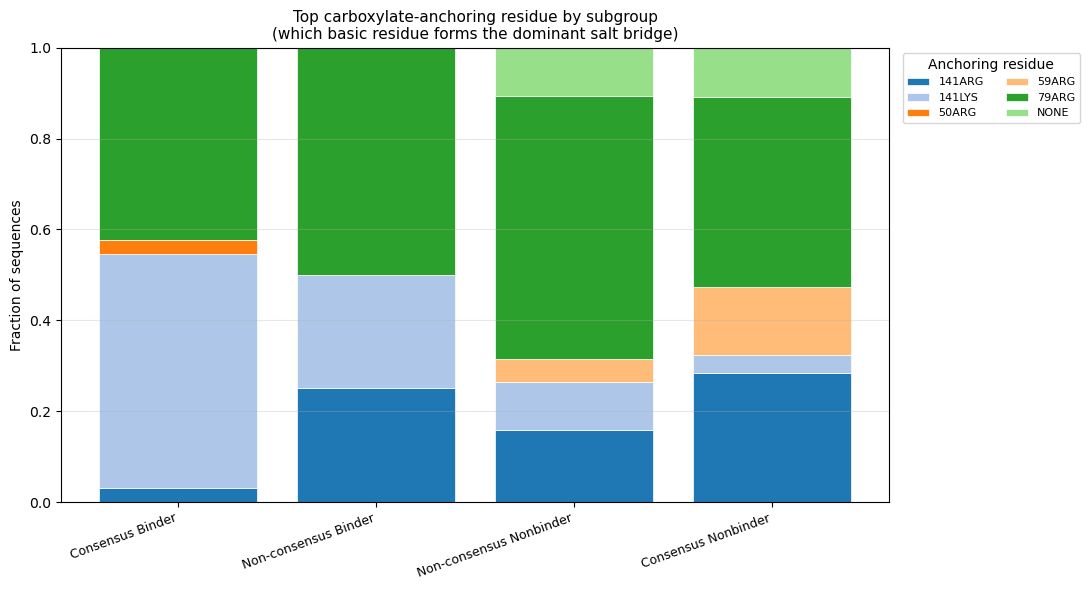

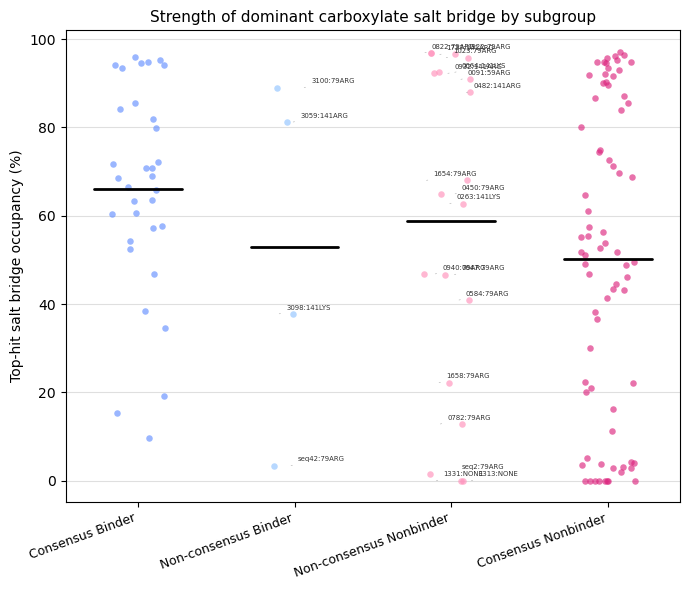


=== Top-hit occupancy: pairwise Mann-Whitney U (Bonferroni) ===
  CB vs NCB: p=1.0000 ns
  CB vs NCNB: p=1.0000 ns
  CB vs CNB: p=0.2014 ns
  NCB vs NCNB: p=1.0000 ns
  NCB vs CNB: p=1.0000 ns
  NCNB vs CNB: p=1.0000 ns

Outputs written to: /Users/ivanatang/Library/CloudStorage/OneDrive-UCB-O365/Shirts Lab/LCA_boltz_models/analysis/nonconsensus_salt_bridge


In [15]:
# ══════════════════════════════════════════════════════════════════════════════
# Salt bridge analysis: which basic residue anchors the LCA carboxylate?
# Loads saltbridge_occupancy_full.csv per sequence, compares the dominant
# anchoring residue across the four subgroups.
# ══════════════════════════════════════════════════════════════════════════════

SB_SUBDIR  = 'salt_bridge'
OCC_FILE   = 'saltbridge_occupancy_full.csv'
OUT_DIR_SB = os.path.join(base, 'analysis', 'nonconsensus_salt_bridge')
os.makedirs(OUT_DIR_SB, exist_ok=True)

# ── Load every sequence's occupancy table ─────────────────────────────────────
occ_all, missing = [], []
for _, row in ft.iterrows():
    fpath = os.path.join(base, TYPE_SUBDIR[row['seq_type']],
                         row['folder_name'], runrel, SB_SUBDIR, OCC_FILE)
    if not os.path.exists(fpath):
        missing.append(row['folder_name']); continue
    df = pd.read_csv(fpath)
    if df.empty:
        occ_all.append(pd.DataFrame([{
            'seq_id': row['folder_name'], 'resid': np.nan, 'resname': 'NONE',
            'mean_dist_A': np.nan, 'min_dist_A': np.nan, 'occupancy_pct': 0.0,
            'subgroup': row['subgroup'], 'motif_score': row['motif_score']}]))
        continue
    df['subgroup'], df['motif_score'] = row['subgroup'], row['motif_score']
    occ_all.append(df)

if missing:
    print(f"Missing occupancy files ({len(missing)}): {missing[:5]}"
          + (f" ... +{len(missing)-5} more" if len(missing) > 5 else ""))

occ_df = pd.concat(occ_all, ignore_index=True)
print(f"Loaded salt bridge data for {occ_df['seq_id'].nunique()} sequences")

# ── Per-sequence top anchoring residue ────────────────────────────────────────
top_hit = (occ_df.sort_values('occupancy_pct', ascending=False)
                  .groupby('seq_id', as_index=False).first())

print("\n=== Top anchoring residue per subgroup ===")
for sg in SUBGROUP_ORDER:
    sub = top_hit[top_hit['subgroup'] == sg]
    if sub.empty: continue
    counts = sub.groupby(['resid', 'resname']).size().sort_values(ascending=False)
    print(f"\n{SUBGROUP_LABEL[sg]} (n={len(sub)}):")
    for (resid, resname), c in counts.head(5).items():
        rid = int(resid) if not np.isnan(resid) else 'NONE'
        mean_occ = sub.loc[sub['resid'] == resid, 'occupancy_pct'].mean()
        print(f"   resid {rid} ({resname}): top anchor in {c}/{len(sub)} seqs, "
              f"mean occupancy {mean_occ:.1f}%")

# ── Most commonly involved residues across ALL sequences (any occupancy) ──────
print("\n=== Most frequently involved residues (any occupancy) by subgroup ===")
involvement = (occ_df[occ_df['resname'] != 'NONE']
               .groupby(['subgroup', 'resid', 'resname'])
               .agg(n_seqs=('seq_id', 'nunique'),
                    mean_occ=('occupancy_pct', 'mean')).reset_index())
for sg in SUBGROUP_ORDER:
    sub = involvement[involvement['subgroup'] == sg].sort_values('n_seqs', ascending=False)
    if sub.empty: continue
    n_total = ft[ft['subgroup'] == sg].shape[0]
    print(f"\n{SUBGROUP_LABEL[sg]}:")
    for _, r in sub.head(5).iterrows():
        print(f"   resid {int(r['resid'])} ({r['resname']}): present in "
              f"{int(r['n_seqs'])}/{n_total} seqs, mean occupancy {r['mean_occ']:.1f}%")

# ── Figure 1: stacked bar — top anchor residue composition per subgroup ──────
top_hit['resid_label'] = top_hit.apply(
    lambda r: f"{int(r['resid'])}{r['resname']}" if not pd.isna(r['resid']) else 'NONE', axis=1)
top_resids = top_hit['resid_label'].value_counts().head(10).index.tolist()
top_hit['resid_plot'] = top_hit['resid_label'].where(
    top_hit['resid_label'].isin(top_resids), 'other')

pivot = top_hit.groupby(['subgroup', 'resid_plot']).size().unstack(fill_value=0).reindex(SUBGROUP_ORDER)
pivot_frac = pivot.div(pivot.sum(axis=1), axis=0)

fig1, ax1 = plt.subplots(figsize=(11, 6))
bottom = np.zeros(len(pivot_frac))
cmap = plt.get_cmap('tab20')
for i, col in enumerate(pivot_frac.columns):
    ax1.bar(range(len(pivot_frac)), pivot_frac[col].values, bottom=bottom,
            label=col, color=cmap(i % 20), edgecolor='white', linewidth=0.5)
    bottom += pivot_frac[col].values
ax1.set_xticks(range(len(pivot_frac)))
ax1.set_xticklabels([SUBGROUP_LABEL[sg] for sg in pivot_frac.index], rotation=20, ha='right', fontsize=9)
ax1.set_ylabel('Fraction of sequences', fontsize=10)
ax1.set_title('Top carboxylate-anchoring residue by subgroup\n'
              '(which basic residue forms the dominant salt bridge)', fontsize=11)
ax1.legend(title='Anchoring residue', fontsize=8, ncol=2, bbox_to_anchor=(1.01, 1.0), loc='upper left')
ax1.set_ylim(0, 1.0); ax1.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
fig1.savefig(os.path.join(OUT_DIR_SB, 'saltbridge_anchor_by_subgroup.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 2: strip plot — top-hit occupancy % by subgroup ───────────────────
fig2, ax2 = plt.subplots(figsize=(7, 6))
_rng2 = np.random.default_rng(42)
all_vals = top_hit['occupancy_pct'].dropna().values
data_ymax = all_vals.max() if len(all_vals) else 100
data_range = (all_vals.max() - all_vals.min()) if len(all_vals) > 1 else 100
gp = {g: i for i, g in enumerate(SUBGROUP_ORDER)}

for x_pos, sg in enumerate(SUBGROUP_ORDER):
    vals = top_hit.loc[top_hit['subgroup'] == sg, 'occupancy_pct'].dropna().values
    if len(vals) == 0: continue
    jitter = _rng2.uniform(-0.18, 0.18, size=len(vals))
    ax2.scatter(x_pos + jitter, vals, color=SUBGROUP_COLOR[sg], alpha=0.65, s=22, linewidths=0, zorder=2)
    ax2.plot([x_pos - 0.28, x_pos + 0.28], [np.mean(vals)] * 2, color='black', lw=2.0, solid_capstyle='round', zorder=3)
    if sg in ('nonconsensus_binder', 'nonconsensus_nonbinder'):
        sub_rows = top_hit[top_hit['subgroup'] == sg].dropna(subset=['occupancy_pct']).reset_index(drop=True)
        jj = _rng2.uniform(-0.18, 0.18, size=len(sub_rows))
        for k, srow in sub_rows.iterrows():
            ax2.annotate(f"{short_name(srow['seq_id'])}:{srow['resid_label']}",
                         xy=(x_pos + jj[k], srow['occupancy_pct']),
                         xytext=(5, 3), textcoords='offset points', fontsize=5,
                         color='#333333', arrowprops=dict(arrowstyle='-', lw=0.4, color='#aaaaaa'))

ax2.set_xticks(range(len(SUBGROUP_ORDER)))
ax2.set_xticklabels([SUBGROUP_LABEL[sg] for sg in SUBGROUP_ORDER], rotation=20, ha='right', fontsize=9)
ax2.set_ylabel('Top-hit salt bridge occupancy (%)', fontsize=10)
ax2.set_title('Strength of dominant carboxylate salt bridge by subgroup', fontsize=11)
ax2.grid(True, axis='y', alpha=0.4)
add_sig_brackets(ax2, gp, compute_pairwise_bonferroni(top_hit, 'occupancy_pct', SUBGROUP_ORDER), data_ymax, data_range)
plt.tight_layout()
fig2.savefig(os.path.join(OUT_DIR_SB, 'saltbridge_occupancy_strip.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Statistics + save ─────────────────────────────────────────────────────────
print("\n=== Top-hit occupancy: pairwise Mann-Whitney U (Bonferroni) ===")
for (g1, g2), p in compute_pairwise_bonferroni(top_hit, 'occupancy_pct', SUBGROUP_ORDER).items():
    if not np.isnan(p):
        print(f"  {SUBGROUP_ABBREV[g1]} vs {SUBGROUP_ABBREV[g2]}: p={p:.4f} {p_label(p)}")

top_hit.to_csv(os.path.join(OUT_DIR_SB, 'saltbridge_top_hit_per_sequence.csv'), index=False)
occ_df.to_csv(os.path.join(OUT_DIR_SB, 'saltbridge_all_occupancy.csv'), index=False)
print(f"\nOutputs written to: {OUT_DIR_SB}")

Salt bridge threshold: residue bridged >= 30% of frames

=== Counts: binder vs nonbinder ===
n_capped    0   1  2
binding             
Binder      4  27  6
Nonbinder  28  61  4

=== Counts: by subgroup ===
n_capped                 0   1  2
subgroup                         
consensus_binder         3  25  5
nonconsensus_binder      1   2  1
nonconsensus_nonbinder   5  13  1
consensus_nonbinder     23  48  3


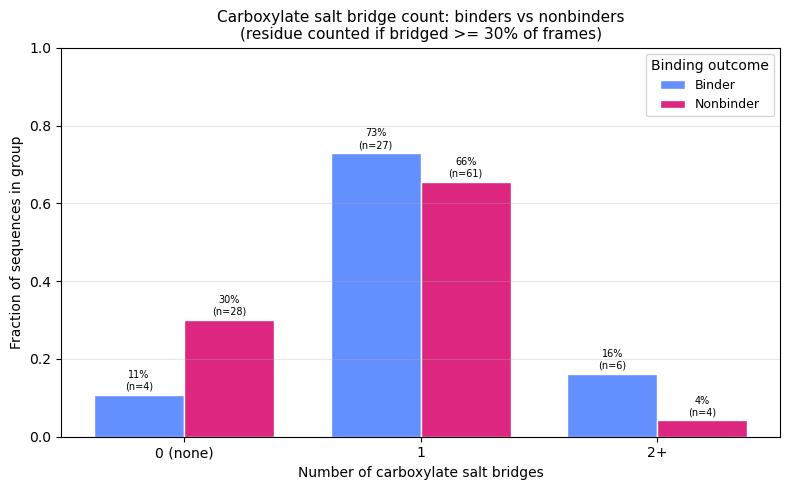

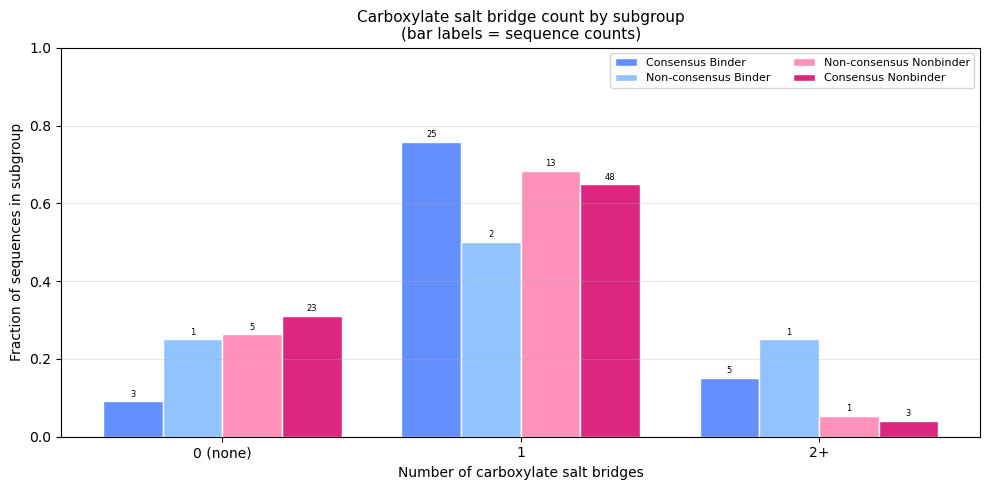


Outputs written to: /Users/ivanatang/Library/CloudStorage/OneDrive-UCB-O365/Shirts Lab/LCA_boltz_models/analysis/nonconsensus_salt_bridge


In [18]:
# ══════════════════════════════════════════════════════════════════════════════
# Count salt bridges per sequence; compare binder vs nonbinder
# Reads saltbridge_all_occupancy.csv (per-residue carboxylate occupancy).
# A residue "forms a salt bridge" if it is within cutoff of the carboxylate
# for >= BRIDGE_OCC_THRESHOLD % of frames. We count distinct such residues
# per sequence, capped at 2+.
#
# CAVEAT: this is a TIME-AVERAGED count, not a per-frame simultaneity count.
# Two residues each above threshold may be alternating across the trajectory
# (switching) rather than coordinating the carboxylate at the same instant
# (bidentate). To distinguish, a per-frame count is required (separate analysis).
# ══════════════════════════════════════════════════════════════════════════════

BRIDGE_OCC_THRESHOLD = 30.0   # % of frames a residue must be bridged to count

# ── Load aggregated occupancy table ───────────────────────────────────────────
occ_path = os.path.join(OUT_DIR_SB, 'saltbridge_all_occupancy.csv')
occ_sb = pd.read_csv(occ_path)

# ── Count distinct bridging residues per sequence ─────────────────────────────
real = occ_sb[(occ_sb['resname'] != 'NONE') &
              (occ_sb['occupancy_pct'] >= BRIDGE_OCC_THRESHOLD)]
n_bridges = real.groupby('seq_id')['resid'].nunique()

# Ensure every sequence is represented (0 bridges for those with none above thresh)
all_seq   = occ_sb['seq_id'].drop_duplicates()
n_bridges = (n_bridges.reindex(all_seq, fill_value=0)
                      .rename('n_bridges').reset_index())
n_bridges['n_capped'] = n_bridges['n_bridges'].clip(upper=2)   # 0, 1, 2+

# ── Attach subgroup + binary binding label (from ft, authoritative) ──────────
n_bridges = n_bridges.merge(
    ft[['folder_name', 'subgroup']].rename(columns={'folder_name': 'seq_id'}),
    on='seq_id', how='left')

BINDER_SUBGROUPS = {'consensus_binder', 'nonconsensus_binder'}
n_bridges['binding'] = n_bridges['subgroup'].apply(
    lambda s: 'Binder' if s in BINDER_SUBGROUPS else 'Nonbinder')

categories = [0, 1, 2]
cat_labels = ['0 (none)', '1', '2+']

# ── Print raw count tables (so fractions aren't read without n) ───────────────
print(f"Salt bridge threshold: residue bridged >= {BRIDGE_OCC_THRESHOLD:.0f}% of frames\n")
print("=== Counts: binder vs nonbinder ===")
ct_bind = (n_bridges.groupby(['binding', 'n_capped']).size()
                    .unstack(fill_value=0).reindex(columns=categories, fill_value=0))
print(ct_bind.to_string())
print("\n=== Counts: by subgroup ===")
ct_sg = (n_bridges.groupby(['subgroup', 'n_capped']).size()
                  .unstack(fill_value=0).reindex(columns=categories, fill_value=0)
                  .reindex(SUBGROUP_ORDER))
print(ct_sg.to_string())

# ══════════════════════════════════════════════════════════════════════════════
# Plot 1: binder vs nonbinder
# ══════════════════════════════════════════════════════════════════════════════
frac_bind = ct_bind.div(ct_bind.sum(axis=1), axis=0)
group_colors = {'Binder': '#648FFF', 'Nonbinder': '#DC267F'}
groups = ['Binder', 'Nonbinder']

x = np.arange(len(categories))
w = 0.38
fig1, ax1 = plt.subplots(figsize=(8, 5))
for i, g in enumerate(groups):
    vals = [frac_bind.loc[g, c] if g in frac_bind.index else 0 for c in categories]
    bars = ax1.bar(x + (i - 0.5) * w, vals, w, label=g,
                   color=group_colors[g], edgecolor='white')
    for c, b in zip(categories, bars):
        n = ct_bind.loc[g, c] if g in ct_bind.index else 0
        ax1.annotate(f"{b.get_height()*100:.0f}%\n(n={n})",
                     xy=(b.get_x() + b.get_width()/2, b.get_height()),
                     xytext=(0, 2), textcoords='offset points',
                     ha='center', va='bottom', fontsize=7)
ax1.set_xticks(x); ax1.set_xticklabels(cat_labels)
ax1.set_xlabel('Number of carboxylate salt bridges', fontsize=10)
ax1.set_ylabel('Fraction of sequences in group', fontsize=10)
ax1.set_title('Carboxylate salt bridge count: binders vs nonbinders\n'
              f'(residue counted if bridged >= {BRIDGE_OCC_THRESHOLD:.0f}% of frames)',
              fontsize=11)
ax1.set_ylim(0, 1.0); ax1.grid(True, axis='y', alpha=0.3)
ax1.legend(title='Binding outcome', fontsize=9)
plt.tight_layout()
fig1.savefig(os.path.join(OUT_DIR_SB, 'saltbridge_count_binder_vs_nonbinder.png'),
             dpi=150, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# Plot 2: by four subgroups
# ══════════════════════════════════════════════════════════════════════════════
frac_sg = ct_sg.div(ct_sg.sum(axis=1), axis=0)
w2 = 0.2
fig2, ax2 = plt.subplots(figsize=(10, 5))
for i, sg in enumerate(SUBGROUP_ORDER):
    vals = [frac_sg.loc[sg, c] if sg in frac_sg.index else 0 for c in categories]
    offset = (i - 1.5) * w2
    bars = ax2.bar(x + offset, vals, w2, label=SUBGROUP_LABEL[sg],
                   color=SUBGROUP_COLOR[sg], edgecolor='white')
    for c, b in zip(categories, bars):
        n = ct_sg.loc[sg, c] if sg in ct_sg.index else 0
        if b.get_height() > 0:
            ax2.annotate(f"{n}", xy=(b.get_x() + b.get_width()/2, b.get_height()),
                         xytext=(0, 2), textcoords='offset points',
                         ha='center', va='bottom', fontsize=6)
ax2.set_xticks(x); ax2.set_xticklabels(cat_labels)
ax2.set_xlabel('Number of carboxylate salt bridges', fontsize=10)
ax2.set_ylabel('Fraction of sequences in subgroup', fontsize=10)
ax2.set_title('Carboxylate salt bridge count by subgroup\n'
              '(bar labels = sequence counts)', fontsize=11)
ax2.set_ylim(0, 1.0); ax2.grid(True, axis='y', alpha=0.3)
ax2.legend(fontsize=8, ncol=2)
plt.tight_layout()
fig2.savefig(os.path.join(OUT_DIR_SB, 'saltbridge_count_by_subgroup.png'),
             dpi=150, bbox_inches='tight')
plt.show()

# ── Save per-sequence bridge counts ───────────────────────────────────────────
n_bridges.to_csv(os.path.join(OUT_DIR_SB, 'saltbridge_count_per_sequence.csv'),
                 index=False)
print(f"\nOutputs written to: {OUT_DIR_SB}")

=== Mean occupancy (%) per position+residue ===
binding  Binder  Nonbinder
50ARG      2.12       0.00
59ARG      0.00      11.30
79ARG     34.99      23.53
141ARG     4.77      19.04
141LYS    39.64       4.80


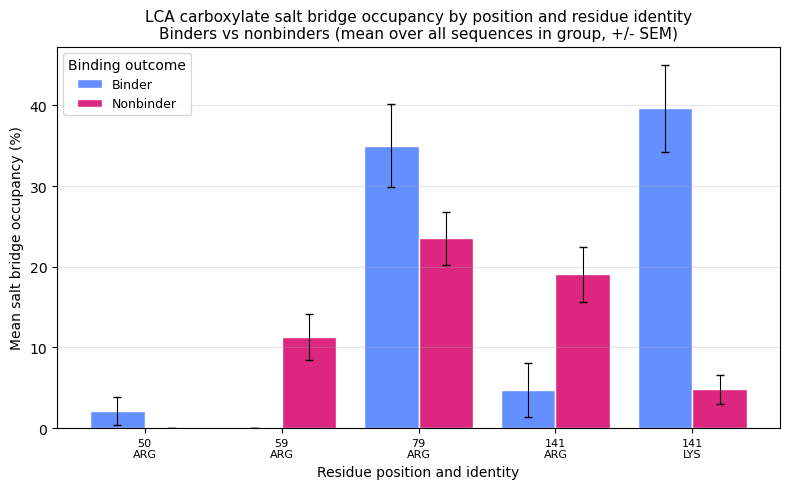


Outputs written to: /Users/ivanatang/Library/CloudStorage/OneDrive-UCB-O365/Shirts Lab/LCA_boltz_models/analysis/nonconsensus_salt_bridge


In [20]:
# ══════════════════════════════════════════════════════════════════════════════
# Mean carboxylate salt bridge occupancy per position+residue: binders vs nonbinders
# Reads saltbridge_all_occupancy.csv. Splits each position by every amino acid
# that appears there (e.g. 141ARG vs 141LYS as separate bars). Averages occupancy
# across ALL sequences in the group (absent residue/identity = 0% occupancy).
# ══════════════════════════════════════════════════════════════════════════════

MIN_MEAN_OCC_TO_PLOT = 1.0   # only show identities with >=1% mean occupancy in a group

# ── Load occupancy table ──────────────────────────────────────────────────────
occ_path = os.path.join(OUT_DIR_SB, 'saltbridge_all_occupancy.csv')
occ_sb   = pd.read_csv(occ_path)

# ── Per-sequence binding label (from ft, authoritative) ──────────────────────
BINDER_SUBGROUPS = {'consensus_binder', 'nonconsensus_binder'}
seq_meta = ft[['folder_name', 'subgroup']].rename(columns={'folder_name': 'seq_id'}).copy()
seq_meta['binding'] = seq_meta['subgroup'].apply(
    lambda s: 'Binder' if s in BINDER_SUBGROUPS else 'Nonbinder')

# ── Build composite position+residue label ────────────────────────────────────
real = occ_sb[occ_sb['resname'] != 'NONE'].copy()
real['pos_label'] = real['resid'].astype(int).astype(str) + real['resname']  # '141LYS'

# Map label -> (resid, resname) for sorting and axis annotation
label_meta = (real[['pos_label', 'resid', 'resname']]
              .drop_duplicates('pos_label')
              .set_index('pos_label'))

# ── Build seq_id x (pos_label) occupancy matrix (absent -> 0) ─────────────────
pivot = real.pivot_table(index='seq_id', columns='pos_label',
                         values='occupancy_pct', aggfunc='max', fill_value=0)
pivot = pivot.reindex(seq_meta['seq_id'], fill_value=0)        # include 0-bridge seqs
pivot = pivot.join(seq_meta.set_index('seq_id')['binding'])

# ── Mean +/- SEM occupancy per identity per group ────────────────────────────
grp           = pivot.groupby('binding')
mean_by_group = grp.mean(numeric_only=True)
sem_by_group  = grp.sem(numeric_only=True)

# ── Choose identities to plot, sorted by (resid, resname) ────────────────────
keep = [lbl for lbl in mean_by_group.columns
        if mean_by_group[lbl].max() >= MIN_MEAN_OCC_TO_PLOT]
keep = sorted(keep, key=lambda lbl: (int(label_meta.loc[lbl, 'resid']),
                                     label_meta.loc[lbl, 'resname']))

print("=== Mean occupancy (%) per position+residue ===")
summary_tbl = mean_by_group[keep].T.round(2)
print(summary_tbl.to_string())

# ── Grouped bar plot ──────────────────────────────────────────────────────────
groups       = ['Binder', 'Nonbinder']
group_colors = {'Binder': '#648FFF', 'Nonbinder': '#DC267F'}
x = np.arange(len(keep))
w = 0.4

fig, ax = plt.subplots(figsize=(max(8, len(keep) * 0.9), 5))
for i, g in enumerate(groups):
    means = [mean_by_group.loc[g, lbl] if g in mean_by_group.index else 0 for lbl in keep]
    sems  = [sem_by_group.loc[g, lbl]  if g in sem_by_group.index  else 0 for lbl in keep]
    ax.bar(x + (i - 0.5) * w, means, w, yerr=sems, capsize=3,
           label=g, color=group_colors[g], edgecolor='white',
           error_kw=dict(lw=0.8))

# x labels: position number on top, residue identity below
xlabels = [f"{int(label_meta.loc[lbl,'resid'])}\n{label_meta.loc[lbl,'resname']}"
           for lbl in keep]
ax.set_xticks(x)
ax.set_xticklabels(xlabels, fontsize=8)
ax.set_xlabel('Residue position and identity', fontsize=10)
ax.set_ylabel('Mean salt bridge occupancy (%)', fontsize=10)
ax.set_title('LCA carboxylate salt bridge occupancy by position and residue identity\n'
             'Binders vs nonbinders (mean over all sequences in group, +/- SEM)',
             fontsize=11)
ax.grid(True, axis='y', alpha=0.3)
ax.legend(title='Binding outcome', fontsize=9)
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR_SB, 'saltbridge_occupancy_by_position_residue.png'),
            dpi=150, bbox_inches='tight')
plt.show()

#summary_tbl.to_csv(os.path.join(OUT_DIR_SB, 'saltbridge_mean_occupancy_by_position_residue.csv'))
print(f"\nOutputs written to: {OUT_DIR_SB}")